In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
print("GRADIENT DESCENT — Step by step")
print("="*45)

GRADIENT DESCENT — Step by step


In [10]:
x  = 5.0   
lr = 0.1

In [11]:
history_x    = [x]
history_loss = [x**2]

In [12]:
for step in range(25):
    loss = x**2
    gradient = 2*x
    x = x=lr*gradient
    history_x.append(x)
    history_loss.append(x**2)
    if step < 6:
        print(f"Step {step+1:2d}: x={x:7.4f}  "
              f"loss={loss:7.4f}  gradient={gradient:7.4f}")

print(f"\nFinal x = {x:.8f}")
print(f"True minimum = 0.0")

Step  1: x= 1.0000  loss=25.0000  gradient=10.0000
Step  2: x= 0.2000  loss= 1.0000  gradient= 2.0000
Step  3: x= 0.0400  loss= 0.0400  gradient= 0.4000
Step  4: x= 0.0080  loss= 0.0016  gradient= 0.0800
Step  5: x= 0.0016  loss= 0.0001  gradient= 0.0160
Step  6: x= 0.0003  loss= 0.0000  gradient= 0.0032

Final x = 0.00000000
True minimum = 0.0


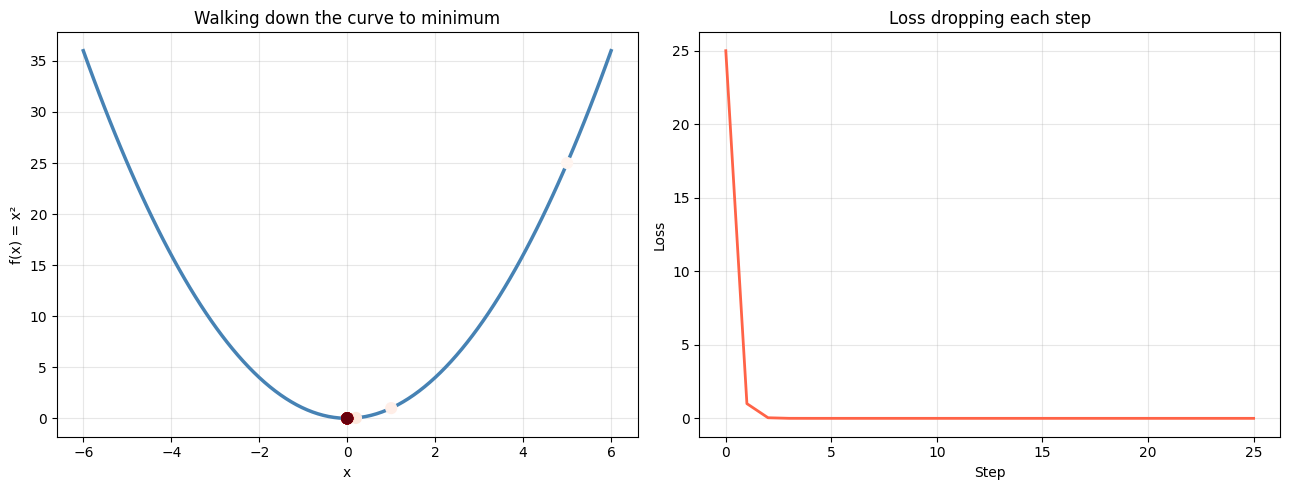

In [13]:
x_range = np.linspace(-6, 6, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: path on the curve
axes[0].plot(x_range, x_range**2, 'steelblue', lw=2.5)
axes[0].scatter(history_x, [h**2 for h in history_x],
                c=range(len(history_x)),
                cmap='Reds', zorder=5, s=60)
axes[0].set_title('Walking down the curve to minimum')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x) = x²')
axes[0].grid(alpha=0.3)

# Right: loss over steps
axes[1].plot(history_loss, 'tomato', lw=2)
axes[1].set_title('Loss dropping each step')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [14]:
print("\nEXPERIMENTS — learning rate matters a lot")
print("="*45)

configs = [
    (0.001, 'too small — barely moves'),
    (0.1,   'just right — clean descent'),
    (0.9,   'too large — overshoots'),
    (1.1,   'way too large — DIVERGES'),
]

for lr_test, label in configs:
    x_test = 5.0
    losses  = []
    
    for _ in range(20):
        loss     = x_test ** 2
        gradient = 2 * x_test
        x_test   = x_test - lr_test * gradient
        losses.append(loss)
        
        if abs(x_test) > 1e6:  # exploding
            losses.append(float('inf'))
            break
    
    final = losses[-1]
    status = '✅' if final < 1 else ('💥' if final == float('inf') else '⚠️')
    print(f"lr={lr_test:<5} | {status} {label:<30} | "
          f"final loss: {final:.2f}" if final != float('inf')
          else f"lr={lr_test:<5} | {status} {label}")


EXPERIMENTS — learning rate matters a lot
lr=0.001 | ⚠️ too small — barely moves       | final loss: 23.17
lr=0.1   | ✅ just right — clean descent     | final loss: 0.01
lr=0.9   | ✅ too large — overshoots         | final loss: 0.01
lr=1.1   | ⚠️ way too large — DIVERGES       | final loss: 25516.87


In [15]:
print("\n\nGRADIENT DESCENT WITH 2 VARIABLES")
print("f(w, b) = w² + b²  — minimum at w=0, b=0")
print("="*45)

w  = 4.0
b  = 3.0
lr = 0.1

for step in range(20):
    loss  = w**2 + b**2
    dw    = 2 * w       # partial derivative w.r.t. w
    db    = 2 * b       # partial derivative w.r.t. b
    w     = w - lr * dw
    b     = b - lr * db
    
    if step < 5:
        print(f"Step {step+1:2d}: w={w:.3f}  b={b:.3f}  loss={loss:.4f}")

print(f"\nFinal: w={w:.6f}, b={b:.6f}")
print(f"True minimum: w=0, b=0")



GRADIENT DESCENT WITH 2 VARIABLES
f(w, b) = w² + b²  — minimum at w=0, b=0
Step  1: w=3.200  b=2.400  loss=25.0000
Step  2: w=2.560  b=1.920  loss=16.0000
Step  3: w=2.048  b=1.536  loss=10.2400
Step  4: w=1.638  b=1.229  loss=6.5536
Step  5: w=1.311  b=0.983  loss=4.1943

Final: w=0.046117, b=0.034588
True minimum: w=0, b=0
